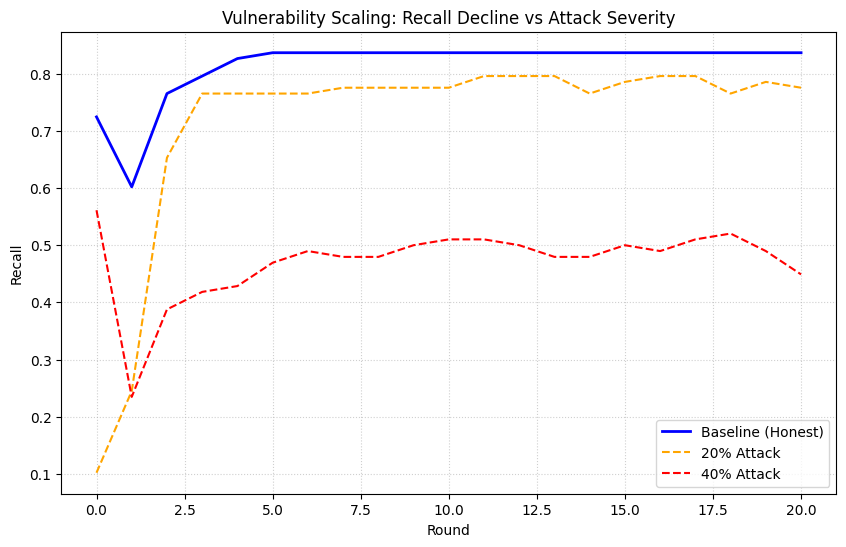

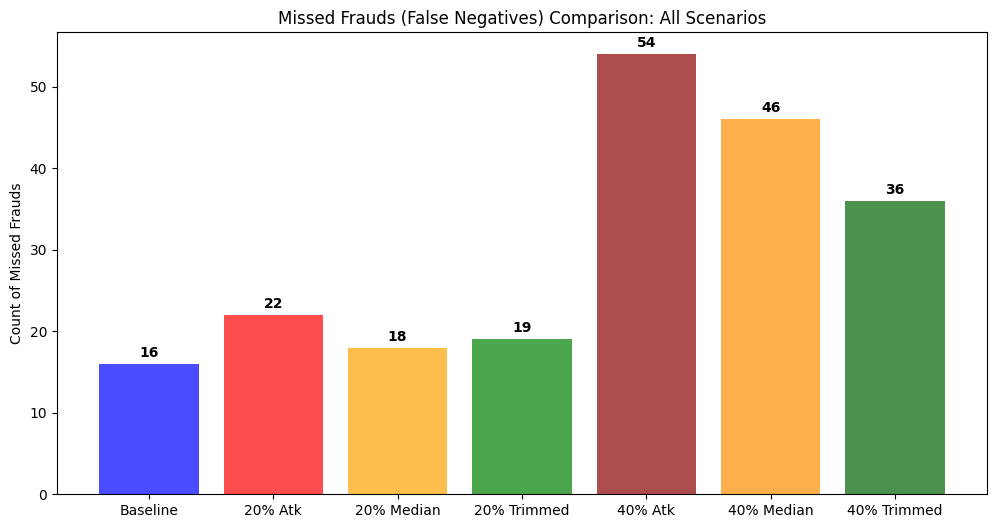

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df_base = pd.read_csv('results/20_rounds/results_baseline_r20.csv')
df_atk_20 = pd.read_csv('results/20_rounds/results_attack_20_r20.csv')
df_atk_40 = pd.read_csv('results/20_rounds/results_attack_40_r20.csv')
df_med_20 = pd.read_csv('results/20_rounds/results_defense_iid_Median_20_r20.csv')
df_trim_20 = pd.read_csv('results/20_rounds/results_defense_iid_TrimmedMean_20_r20.csv')
df_med_40 = pd.read_csv('results/20_rounds/results_defense_iid_Median_40_r20.csv')
df_trim_40 = pd.read_csv('results/20_rounds/results_defense_iid_TrimmedMean_40_r20.csv')

# 1. ATTACK SCALING PLOT
plt.figure(figsize=(10, 6))
plt.plot(df_base['Round'], df_base['Recall'], label='Baseline (Honest)', color='blue', linewidth=2)
plt.plot(df_atk_20['Round'], df_atk_20['Recall'], label='20% Attack', color='orange', linestyle='--')
plt.plot(df_atk_40['Round'], df_atk_40['Recall'], label='40% Attack', color='red', linestyle='--')
plt.title('Vulnerability Scaling: Recall Decline vs Attack Severity')
plt.xlabel('Round')
plt.ylabel('Recall')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 2. MASTER BAR CHART COMPARISON
scenarios = ['Baseline', '20% Atk', '20% Median', '20% Trimmed', '40% Atk', '40% Median', '40% Trimmed']
fn_counts = [int(df_base.iloc[-1]['FN']), int(df_atk_20.iloc[-1]['FN']), 
             int(df_med_20.iloc[-1]['FN']), int(df_trim_20.iloc[-1]['FN']),
             int(df_atk_40.iloc[-1]['FN']), int(df_med_40.iloc[-1]['FN']), 
             int(df_trim_40.iloc[-1]['FN'])]
colors = ['blue', 'red', 'orange', 'green', 'darkred', 'darkorange', 'darkgreen']

plt.figure(figsize=(12, 6))
bars = plt.bar(scenarios, fn_counts, color=colors, alpha=0.7)
plt.title('Missed Frauds (False Negatives) Comparison: All Scenarios')
plt.ylabel('Count of Missed Frauds')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, str(yval), ha='center', va='bottom', fontweight='bold')
plt.show()

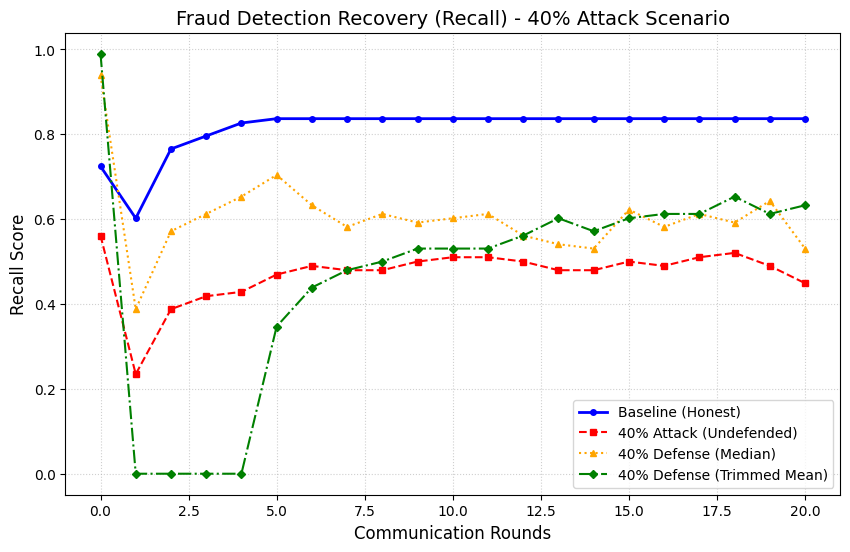

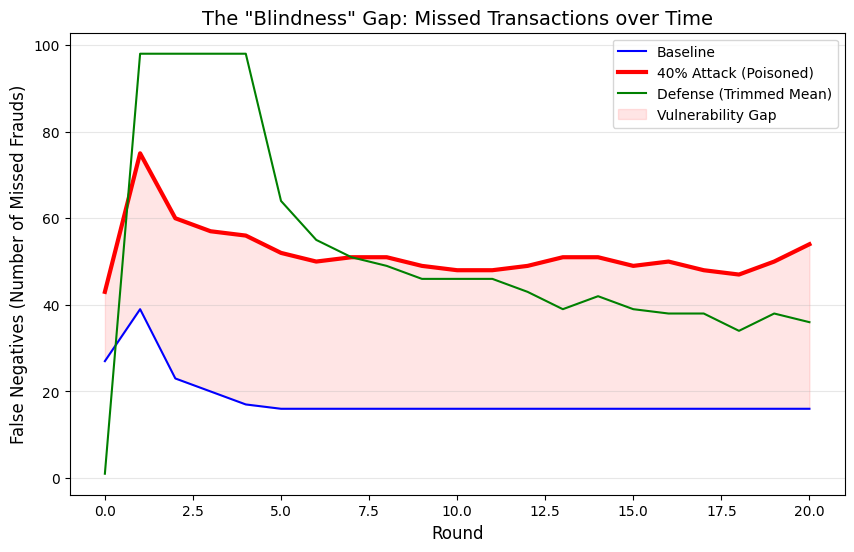

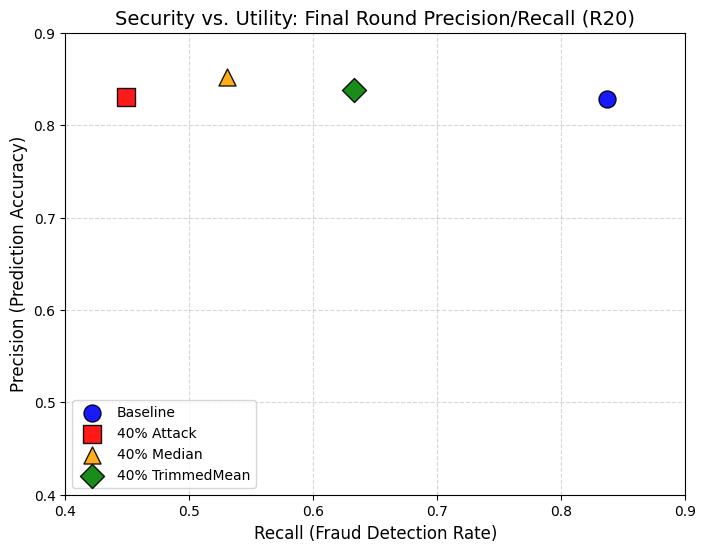

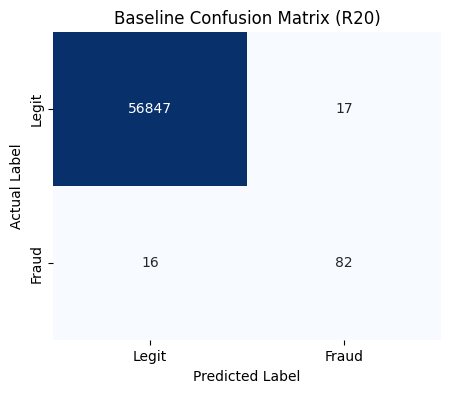

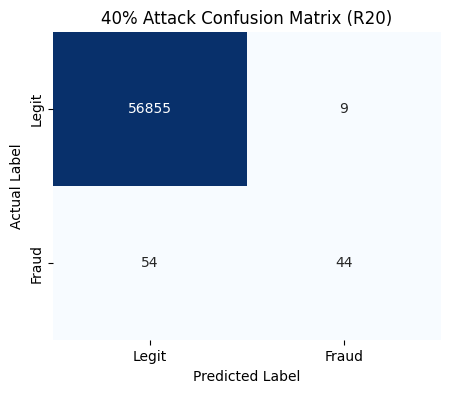

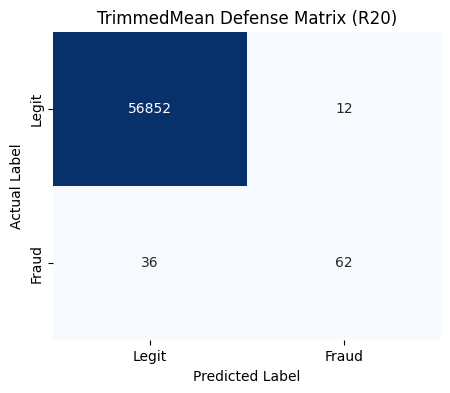

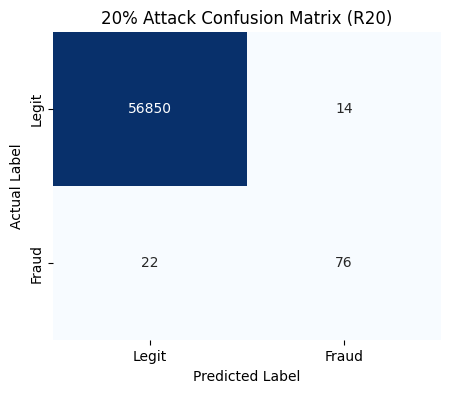

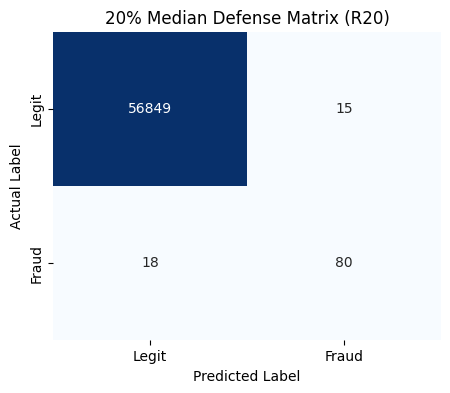

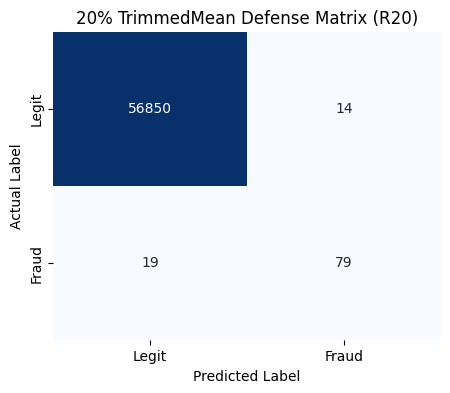

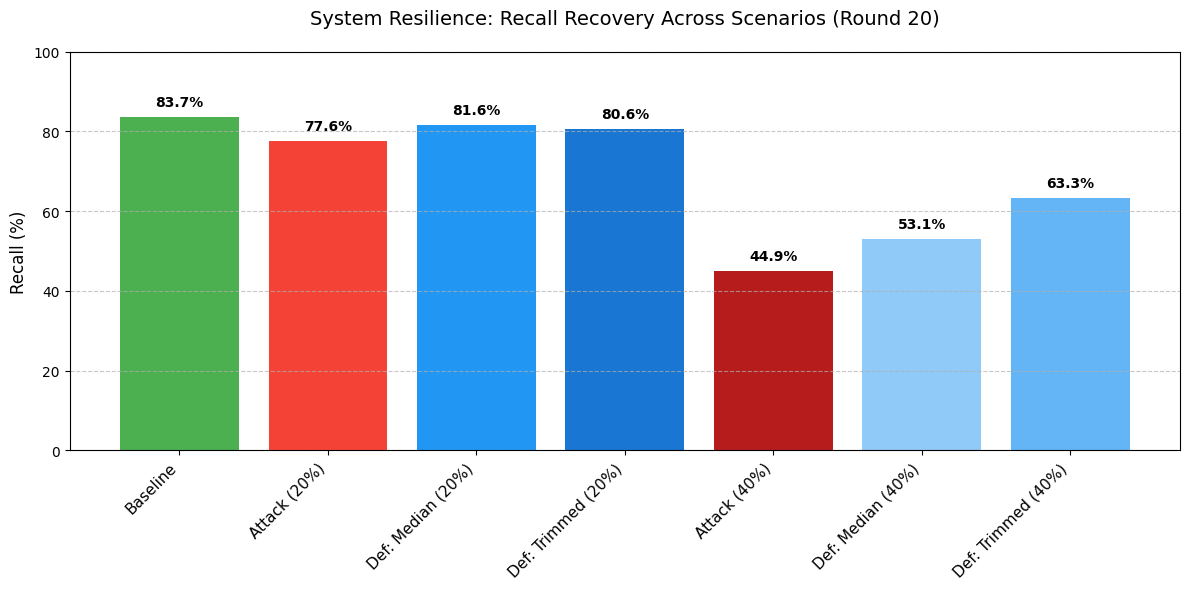

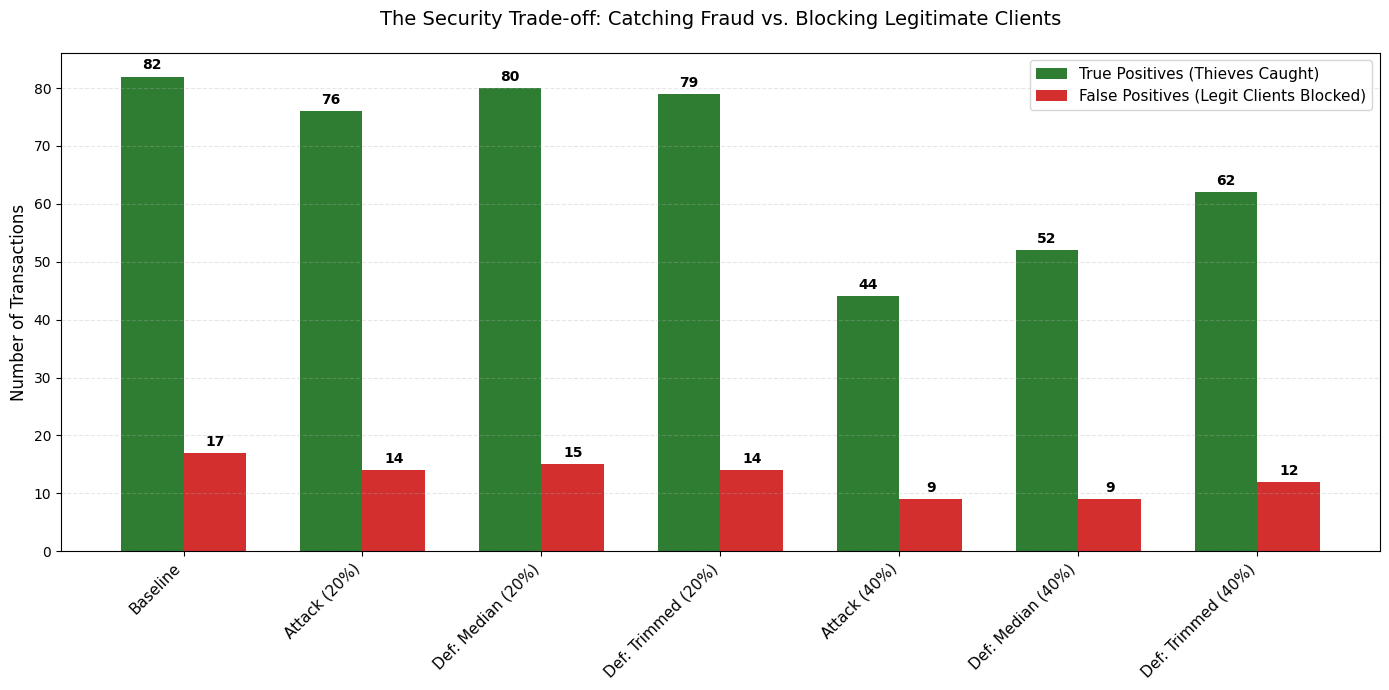

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os



def get_precision(row):
    denom = row['TP'] + row['FP']
    return row['TP'] / denom if denom > 0 else 0

datasets = [df_base, df_atk_20, df_med_20, df_trim_20, df_atk_40, df_med_40, df_trim_40]
for df in datasets:
    df['Precision'] = df.apply(get_precision, axis=1)

last_rounds = [
    ("Baseline", df_base.iloc[-1]),
    ("Attack (20%)", df_atk_20.iloc[-1]),
    ("Def: Median (20%)", df_med_20.iloc[-1]),
    ("Def: Trimmed (20%)", df_trim_20.iloc[-1]),
    ("Attack (40%)", df_atk_40.iloc[-1]),
    ("Def: Median (40%)", df_med_40.iloc[-1]),
    ("Def: Trimmed (40%)", df_trim_40.iloc[-1])
]

df_summary = pd.DataFrame([{
    "Scenario": name, 
    "Recall": row["Recall"] * 100, 
    "True Positives": int(row["TP"]), 
    "False Positives": int(row["FP"])
} for name, row in last_rounds])


#recall
plt.figure(figsize=(10, 6))
plt.plot(df_base['Round'], df_base['Recall'], label='Baseline (Honest)', color='blue', linewidth=2, marker='o', markersize=4)
plt.plot(df_atk_40['Round'], df_atk_40['Recall'], label='40% Attack (Undefended)', color='red', linestyle='--', marker='s', markersize=4)
plt.plot(df_med_40['Round'], df_med_40['Recall'], label='40% Defense (Median)', color='orange', linestyle=':', marker='^', markersize=4)
plt.plot(df_trim_40['Round'], df_trim_40['Recall'], label='40% Defense (Trimmed Mean)', color='green', linestyle='-.', marker='D', markersize=4)

plt.title('Fraud Detection Recovery (Recall) - 40% Attack Scenario', fontsize=14)
plt.xlabel('Communication Rounds', fontsize=12)
plt.ylabel('Recall Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#the gap
plt.figure(figsize=(10, 6))
plt.plot(df_base['Round'], df_base['FN'], label='Baseline', color='blue')
plt.plot(df_atk_40['Round'], df_atk_40['FN'], label='40% Attack (Poisoned)', color='red', linewidth=3)
plt.plot(df_trim_40['Round'], df_trim_40['FN'], label='Defense (Trimmed Mean)', color='green')
plt.fill_between(df_base['Round'], df_base['FN'], df_atk_40['FN'], color='red', alpha=0.1, label='Vulnerability Gap')

plt.title('The "Blindness" Gap: Missed Transactions over Time', fontsize=14)
plt.ylabel('False Negatives (Number of Missed Frauds)', fontsize=12)
plt.xlabel('Round', fontsize=12)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

#precision - recall
scenarios = [
    (df_base, 'Baseline', 'blue', 'o'), 
    (df_atk_40, '40% Attack', 'red', 's'),
    (df_med_40, '40% Median', 'orange', '^'), 
    (df_trim_40, '40% TrimmedMean', 'green', 'D')
]

plt.figure(figsize=(8, 6))
for df, label, color, marker in scenarios:
    last = df.iloc[-1]
    plt.scatter(last['Recall'], last['Precision'], s=150, color=color, label=label, marker=marker, edgecolors='black', alpha=0.9)

plt.title('Security vs. Utility: Final Round Precision/Recall (R20)', fontsize=14)
plt.xlabel('Recall (Fraud Detection Rate)', fontsize=12)
plt.ylabel('Precision (Prediction Accuracy)', fontsize=12)
plt.xlim(0.4, 0.9)
plt.ylim(0.4, 0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.show()

#conf matrices
def plot_cm(df, title):
    row = df.iloc[-1]
    cm = np.array([[int(row['TN']), int(row['FP'])], [int(row['FN']), int(row['TP'])]])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    plt.title(title, fontsize=12)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_cm(df_base, 'Baseline Confusion Matrix (R20)')
plot_cm(df_atk_40, '40% Attack Confusion Matrix (R20)')
plot_cm(df_trim_40, 'TrimmedMean Defense Matrix (R20)')
plot_cm(df_atk_20, '20% Attack Confusion Matrix (R20)')
plot_cm(df_med_20, '20% Median Defense Matrix (R20)')
plot_cm(df_trim_20, '20% TrimmedMean Defense Matrix (R20)')

#recall - recovery
plt.figure(figsize=(12, 6))
x = np.arange(len(df_summary["Scenario"]))
colors = ['#4CAF50', '#F44336', '#2196F3', '#1976D2', '#B71C1C', '#90CAF9', '#64B5F6']
bars = plt.bar(x, df_summary["Recall"], color=colors)

plt.ylabel('Recall (%)', fontsize=12)
plt.title('System Resilience: Recall Recovery Across Scenarios (Round 20)', fontsize=14, pad=20)
plt.xticks(x, df_summary["Scenario"], rotation=45, ha="right", fontsize=11)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f'{yval:.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#TP vs FP
fig, ax = plt.subplots(figsize=(14, 7))
width = 0.35

rects1 = ax.bar(x - width/2, df_summary['True Positives'], width, label='True Positives (Thieves Caught)', color='#2E7D32')
rects2 = ax.bar(x + width/2, df_summary['False Positives'], width, label='False Positives (Legit Clients Blocked)', color='#D32F2F')

ax.set_ylabel('Number of Transactions', fontsize=12)
ax.set_title('The Security Trade-off: Catching Fraud vs. Blocking Legitimate Clients', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_summary['Scenario'], rotation=45, ha="right", fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


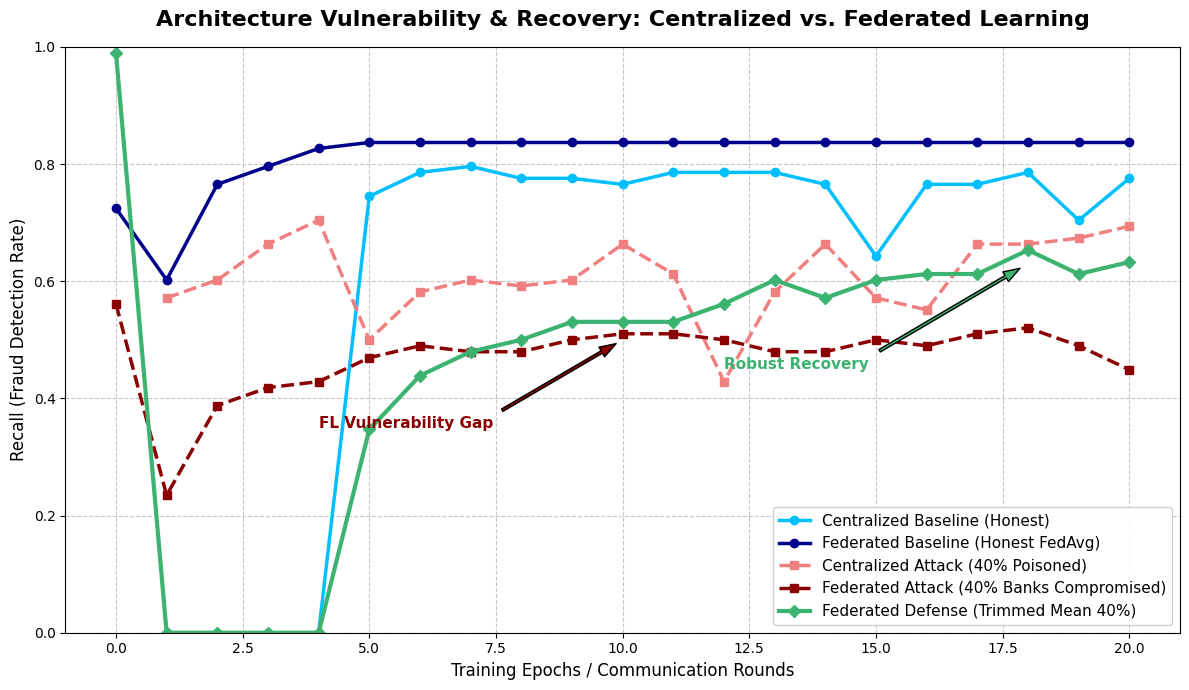

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df_fl_base = pd.read_csv('results/20_rounds/results_baseline_r20.csv')               
df_cent_base = pd.read_csv('results/20_rounds/results_centralized_baseline.csv')     

df_fl_atk40 = pd.read_csv('results/20_rounds/results_attack_40_r20.csv')             
df_cent_atk40 = pd.read_csv('results/20_rounds/results_centralized_attack_40.csv')   

df_fl_def40 = pd.read_csv('results/20_rounds/results_defense_iid_TrimmedMean_40_r20.csv') 

plt.figure(figsize=(12, 7))

plt.plot(df_cent_base['Epoch'], df_cent_base['Recall'], 
         label='Centralized Baseline (Honest)', color='deepskyblue', linewidth=2.5, marker='o')
plt.plot(df_fl_base['Round'], df_fl_base['Recall'], 
         label='Federated Baseline (Honest FedAvg)', color='darkblue', linewidth=2.5, marker='o')

plt.plot(df_cent_atk40['Epoch'], df_cent_atk40['Recall'], 
         label='Centralized Attack (40% Poisoned)', color='lightcoral', linewidth=2.5, linestyle='--', marker='s')
plt.plot(df_fl_atk40['Round'], df_fl_atk40['Recall'], 
         label='Federated Attack (40% Banks Compromised)', color='darkred', linewidth=2.5, linestyle='--', marker='s')

plt.plot(df_fl_def40['Round'], df_fl_def40['Recall'], 
         label='Federated Defense (Trimmed Mean 40%)', color='mediumseagreen', linewidth=3, marker='D')


plt.title('Architecture Vulnerability & Recovery: Centralized vs. Federated Learning', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Training Epochs / Communication Rounds', fontsize=12)
plt.ylabel('Recall (Fraud Detection Rate)', fontsize=12)

plt.ylim(0, 1.0) 
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.7)


plt.annotate('FL Vulnerability Gap', 
             xy=(10, 0.50), xytext=(4, 0.35), 
             arrowprops=dict(facecolor='darkred', shrink=0.05, width=2, headwidth=8),
             fontsize=11, fontweight='bold', color='darkred')

plt.annotate('Robust Recovery', 
             xy=(18, 0.63), xytext=(12, 0.45), 
             arrowprops=dict(facecolor='mediumseagreen', shrink=0.05, width=2, headwidth=8),
             fontsize=11, fontweight='bold', color='mediumseagreen')

plt.tight_layout()
plt.show()

**50 rounds for 40% attack**

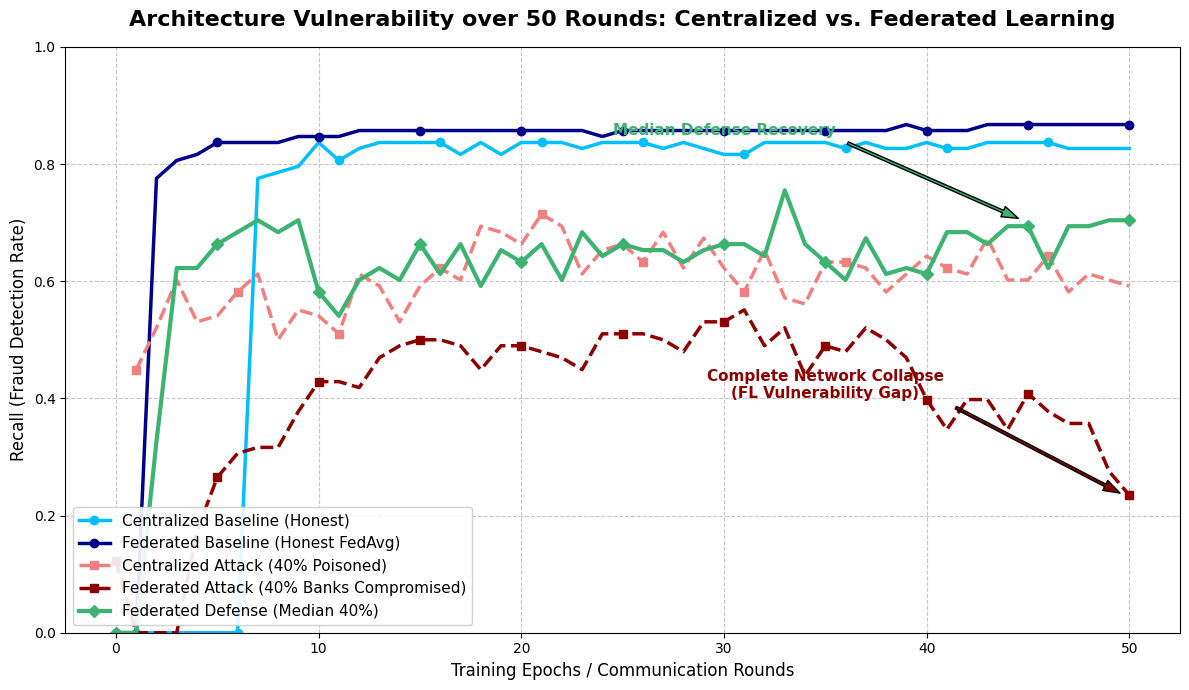

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. LOAD THE 50-ROUND DATA
df_fl_base = pd.read_csv('results/50_rounds/results_baseline_r50.csv')
df_cent_base = pd.read_csv('results/50_rounds/results_centralized_baseline_r50.csv')

df_fl_atk40 = pd.read_csv('results/50_rounds/results_attack_40_r50.csv')
df_cent_atk40 = pd.read_csv('results/50_rounds/results_centralized_attack_40_r50.csv')

# Let's use Median since it performed better over 50 rounds!
df_fl_def40 = pd.read_csv('results/50_rounds/results_defense_Median_40_r50.csv') 

# 2. INITIALIZE PLOT
plt.figure(figsize=(12, 7))

# 3. PLOT HONEST BASELINES (Blues)
plt.plot(df_cent_base['Epoch'], df_cent_base['Recall'], 
         label='Centralized Baseline (Honest)', color='deepskyblue', linewidth=2.5, marker='o', markevery=5)
plt.plot(df_fl_base['Round'], df_fl_base['Recall'], 
         label='Federated Baseline (Honest FedAvg)', color='darkblue', linewidth=2.5, marker='o', markevery=5)

# 4. PLOT ATTACK SCENARIOS (Reds)
plt.plot(df_cent_atk40['Epoch'], df_cent_atk40['Recall'], 
         label='Centralized Attack (40% Poisoned)', color='lightcoral', linewidth=2.5, linestyle='--', marker='s', markevery=5)
plt.plot(df_fl_atk40['Round'], df_fl_atk40['Recall'], 
         label='Federated Attack (40% Banks Compromised)', color='darkred', linewidth=2.5, linestyle='--', marker='s', markevery=5)

# 5. PLOT THE DEFENSE (Green)
plt.plot(df_fl_def40['Round'], df_fl_def40['Recall'], 
         label='Federated Defense (Median 40%)', color='mediumseagreen', linewidth=3, marker='D', markevery=5)

# 6. FORMATTING & LABELS
plt.title('Architecture Vulnerability over 50 Rounds: Centralized vs. Federated Learning', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Training Epochs / Communication Rounds', fontsize=12)
plt.ylabel('Recall (Fraud Detection Rate)', fontsize=12)

# Set Y-axis 
plt.ylim(0, 1.0) 
plt.legend(loc='lower left', fontsize=11, framealpha=0.9) # Moved to left so it doesn't cover lines
plt.grid(True, linestyle='--', alpha=0.7)

# 7. ADD ACADEMIC ANNOTATIONS
# Arrow showing the massive collapse
plt.annotate('Complete Network Collapse\n(FL Vulnerability Gap)', 
             xy=(50, 0.23), xytext=(35, 0.40), 
             arrowprops=dict(facecolor='darkred', shrink=0.05, width=2, headwidth=8),
             fontsize=11, fontweight='bold', color='darkred', ha='center')

# Arrow showing the recovery
plt.annotate('Median Defense Recovery', 
             xy=(45, 0.70), xytext=(30, 0.85), 
             arrowprops=dict(facecolor='mediumseagreen', shrink=0.05, width=2, headwidth=8),
             fontsize=11, fontweight='bold', color='mediumseagreen', ha='center')

plt.tight_layout()
plt.show()

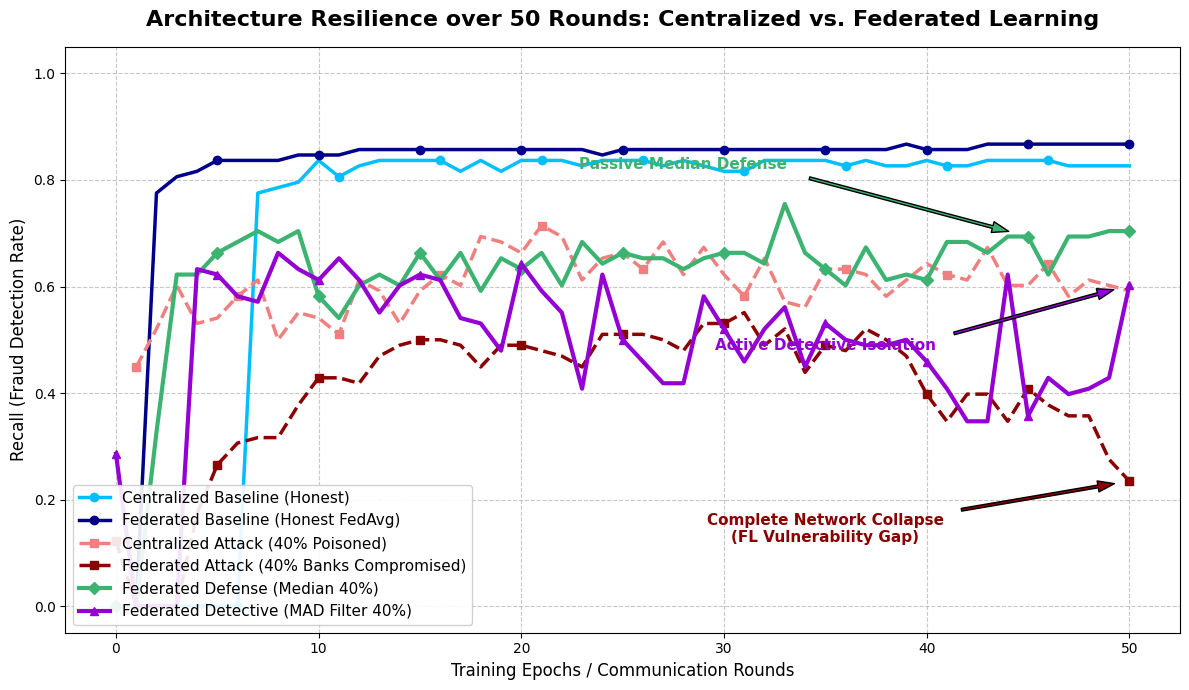

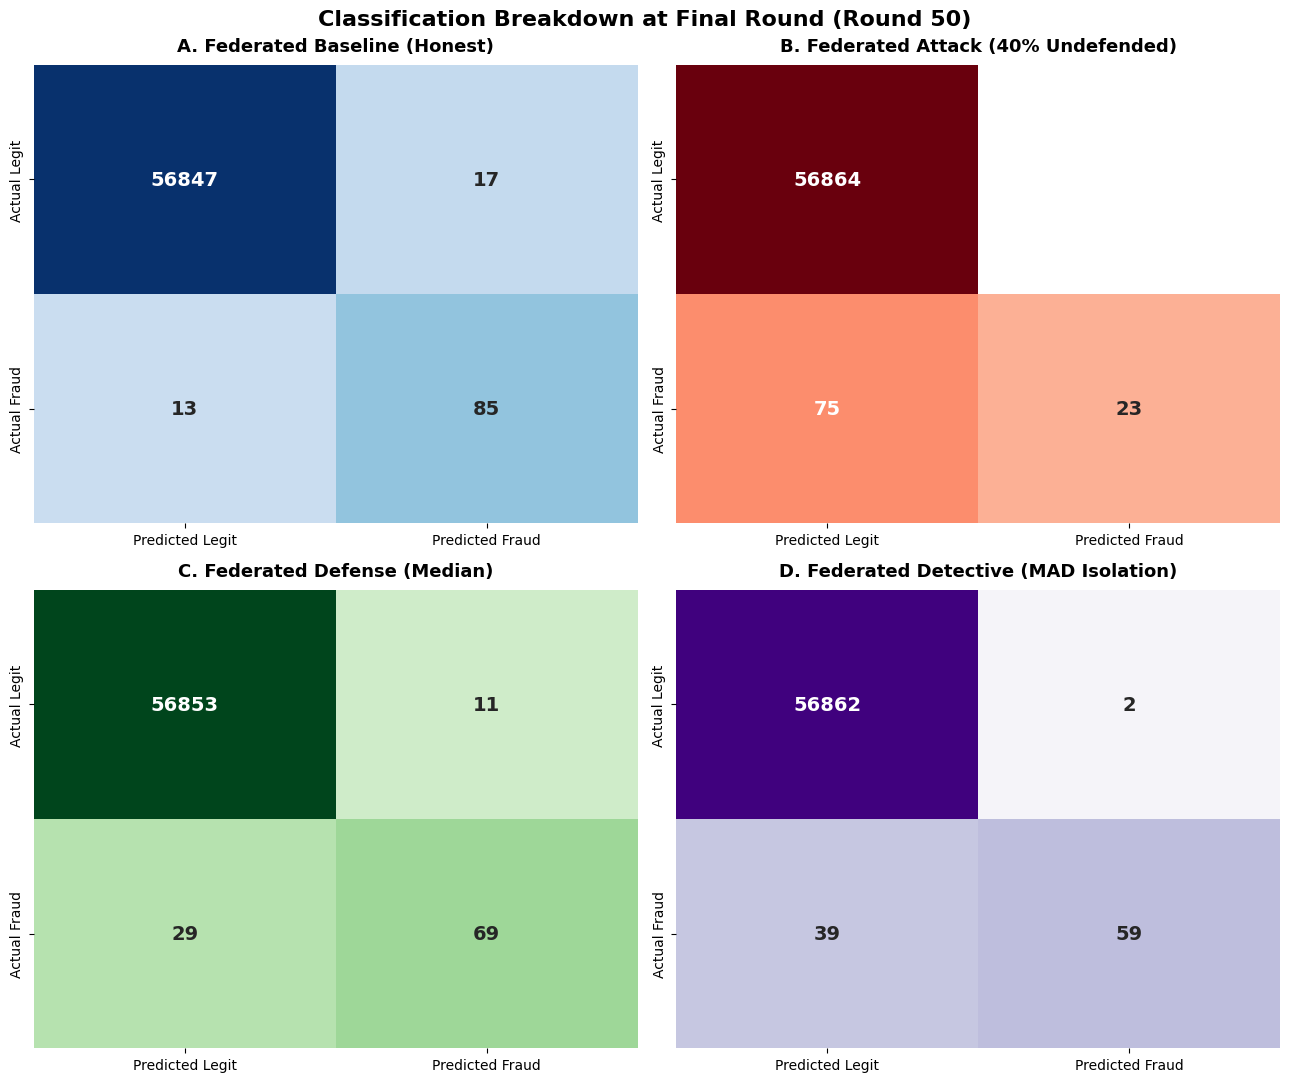

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


df_fl_base = pd.read_csv('results/50_rounds/results_baseline_r50.csv')
df_cent_base = pd.read_csv('results/50_rounds/results_centralized_baseline_r50.csv')

df_fl_atk40 = pd.read_csv('results/50_rounds/results_attack_40_r50.csv')
df_cent_atk40 = pd.read_csv('results/50_rounds/results_centralized_attack_40_r50.csv')

df_fl_med40 = pd.read_csv('results/50_rounds/results_defense_Median_40_r50.csv') 
df_fl_det40 = pd.read_csv('results/50_rounds/results_detective_40_r50.csv') 


plt.figure(figsize=(12, 7))

plt.plot(df_cent_base['Epoch'], df_cent_base['Recall'], 
         label='Centralized Baseline (Honest)', color='deepskyblue', linewidth=2.5, marker='o', markevery=5)
plt.plot(df_fl_base['Round'], df_fl_base['Recall'], 
         label='Federated Baseline (Honest FedAvg)', color='darkblue', linewidth=2.5, marker='o', markevery=5)

plt.plot(df_cent_atk40['Epoch'], df_cent_atk40['Recall'], 
         label='Centralized Attack (40% Poisoned)', color='lightcoral', linewidth=2.5, linestyle='--', marker='s', markevery=5)
plt.plot(df_fl_atk40['Round'], df_fl_atk40['Recall'], 
         label='Federated Attack (40% Banks Compromised)', color='darkred', linewidth=2.5, linestyle='--', marker='s', markevery=5)

# Plot Defenses (Greens and Purples)
plt.plot(df_fl_med40['Round'], df_fl_med40['Recall'], 
         label='Federated Defense (Median 40%)', color='mediumseagreen', linewidth=3, marker='D', markevery=5)
plt.plot(df_fl_det40['Round'], df_fl_det40['Recall'], 
         label='Federated Detective (MAD Filter 40%)', color='darkviolet', linewidth=3, marker='^', markevery=5)

plt.title('Architecture Resilience over 50 Rounds: Centralized vs. Federated Learning', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Training Epochs / Communication Rounds', fontsize=12)
plt.ylabel('Recall (Fraud Detection Rate)', fontsize=12)
plt.ylim(-0.05, 1.05) 
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.7)

plt.annotate('Complete Network Collapse\n(FL Vulnerability Gap)', 
             xy=(50, df_fl_atk40.iloc[-1]['Recall']), xytext=(35, 0.12), 
             arrowprops=dict(facecolor='darkred', shrink=0.08, width=2, headwidth=8),
             fontsize=11, fontweight='bold', color='darkred', ha='center')

plt.annotate('Passive Median Defense', 
             xy=(45, df_fl_med40.iloc[45]['Recall']), xytext=(28, 0.82), 
             arrowprops=dict(facecolor='mediumseagreen', shrink=0.08, width=2, headwidth=8),
             fontsize=11, fontweight='bold', color='mediumseagreen', ha='center')

plt.annotate('Active Detective Isolation', 
             xy=(50, df_fl_det40.iloc[-1]['Recall']), xytext=(35, 0.48), 
             arrowprops=dict(facecolor='darkviolet', shrink=0.08, width=2, headwidth=8),
             fontsize=11, fontweight='bold', color='darkviolet', ha='center')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle('Classification Breakdown at Final Round (Round 50)', fontsize=16, fontweight='bold', y=0.98)

def draw_confusion_matrix(df, ax, title, color_map):
    last_row = df.iloc[-1]
    cm = np.array([
        [int(last_row['TN']), int(last_row['FP'])],
        [int(last_row['FN']), int(last_row['TP'])]
    ])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap=color_map, cbar=False, ax=ax,
                norm=mcolors.LogNorm(vmin=1, vmax=60000),
                xticklabels=['Predicted Legit', 'Predicted Fraud'], 
                yticklabels=['Actual Legit', 'Actual Fraud'],
                annot_kws={"size": 14, "weight": "bold"})
    
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.tick_params(axis='both', which='major', labelsize=10)

draw_confusion_matrix(df_fl_base, axes[0, 0], 'A. Federated Baseline (Honest)', 'Blues')
draw_confusion_matrix(df_fl_atk40, axes[0, 1], 'B. Federated Attack (40% Undefended)', 'Reds')
draw_confusion_matrix(df_fl_med40, axes[1, 0], 'C. Federated Defense (Median)', 'Greens')
draw_confusion_matrix(df_fl_det40, axes[1, 1], 'D. Federated Detective (MAD Isolation)', 'Purples')

plt.tight_layout()
plt.show()